In [1]:
# auto reload modules
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from cns.process import group_samples, add_total_cn
from cns.analyze import *
from cns.utils import only_aut
from cns.data_utils import *

c:\Python39\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
# set font size to 12
plt.rcParams.update({'font.size': 12})

In [4]:
samples_df, cns_df = main_load(segment_type = "1MB", use_filter=True, print_info=True);

Loading samples from PCAWG_samples.tsv
Total samples: 2583
162 samples are CN neutral (below 0.00100)
3 samples have low coverage (below 0.97816)
0 samples do not have exact type
Filtered samples: 2418
Loading samples from TRACERx_samples.tsv
Total samples: 1620
0 samples are CN neutral (below 0.00100)
19 samples have low coverage (below 0.93514)
286 samples do not have exact type
Filtered samples: 1322
Loading samples from TCGA_hg19_samples.tsv
Total samples: 9971
788 samples are CN neutral (below 0.00100)
16 samples have low coverage (below 0.99826)
0 samples do not have exact type
Filtered samples: 9167
Loaded samples: 12907
Loading CNS data from PCAWG_bin_1MB.tsv
Loading CNS data from TRACERx_bin_1MB.tsv
Loading CNS data from TCGA_hg19_bin_1MB.tsv
Total CNS segments: 40759011
Total CNS segments (after filtering): 37116846


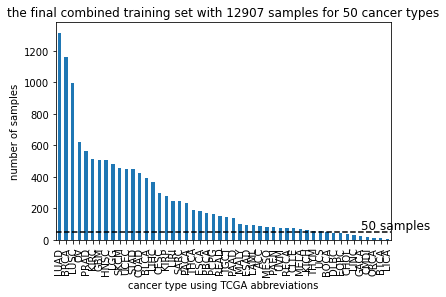

In [5]:
plt.rcParams["figure.figsize"] = (14,5)
samples_df["type"].value_counts().plot(kind="bar")
type_count = len(samples_df["type"].unique())
plt.title("the final combined training set with {} samples for {} cancer types".format(len(samples_df), type_count))
plt.ylabel("number of samples")
plt.xlabel("cancer type using TCGA abbreviations")

# add a horizontal line at 50 samples
plt.axhline(y=50, color='black', linestyle='--')
# add a label to the line
plt.text(45, 50, '50 samples', color = 'black', fontsize = 12, va = 'bottom')

save_cns_fig("cancer_types")

In [6]:
top_6 = samples_df["type"].value_counts().head(6).index
subsample = {cancer_type: add_total_cn(group_samples(select_cns_by_type(cns_df, samples_df, cancer_type))) for cancer_type in top_6}

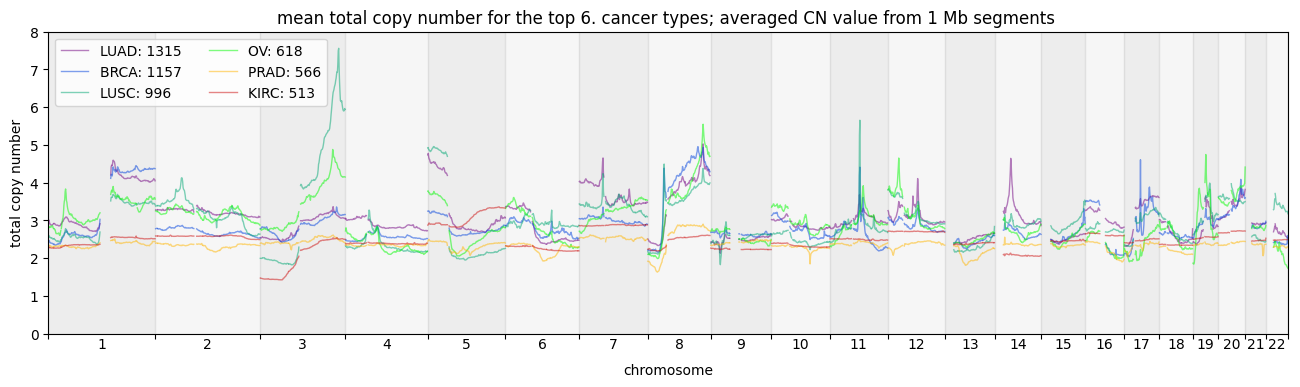

In [7]:
fig, ax = plt.subplots(figsize=(16, 4), dpi=100)
plot_chr_bg(ax, y_max=8)
colors = plt.cm.nipy_spectral(np.linspace(0.05, 0.95, 6))
for i, cancer_type in enumerate(top_6):
	sub_df = subsample[cancer_type]
	sample_count = len(samples_df[samples_df["type"] == cancer_type])
	plot_lines(ax, only_aut(sub_df), cn_column="total_cn", label=f"{cancer_type}: {sample_count}" , color=colors[i], alpha=0.5)
plot_x_ticks(ax)
plt.ylabel("total copy number")
plt.xlabel("chromosome")
ax.legend(ncol=2)

plt.title(f"mean total copy number for the top 6. cancer types; averaged CN value from 1 Mb segments ")
save_cns_fig("top_6_profiles")

Text(0.5, 1.0, 'mean total copy number for 41 types with at least 50 samples')

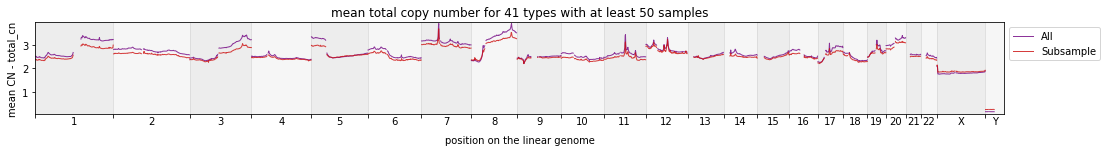

In [16]:
above_50 = samples_df["type"].value_counts().where(lambda x: x >= 50).where(lambda x: x != "Other").dropna().index.values
all_samples = samples_df.query("type in @above_50")
sub_samples = all_samples.reset_index().groupby('type').apply(lambda x: x.sample(n=50, random_state=0), include_groups=False).set_index("sample_id")
# select only 50 samples for each type to obtain balanced mean
sel_dict = { "All": all_samples, "Subsample": sub_samples }
sel_df = pd.concat([add_total_cn(group_samples(select_CNS_samples(cns_df, v), group_name=k)) for k, v in sel_dict.items()])
fig_lines(sel_df, cn_columns="total_cn")
plt.title(f"mean total copy number for {len(above_50)} types with at least 50 samples")